# Random Forest Classifier

## Project Objective

Build a Random Forest classification model and compare its performance with a single Decision Tree classifier.

## Objectives

- Understand ensemble learning
- Build a Decision Tree baseline
- Build a Random Forest classifier
- Compare training and testing performance
- Experiment with different numbers of trees
- Analyse feature importance

## Dataset

Breast Cancer Wisconsin Dataset

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Loading the Dataset

The Breast Cancer Wisconsin dataset is a binary classification dataset.

The objective is to classify tumors as:

- Malignant
- Benign

In [2]:
# Load Breast Cancer Wisconsin dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset loaded successfully!")
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])

Dataset loaded successfully!
Number of rows: 569
Number of features: 30


In [3]:
# Display first five rows

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Display dataset information

print("Dataset shape:", X.shape)
print("\nFeature names:")
print(list(X.columns))







Dataset shape: (569, 30)

Feature names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


In [5]:
# Check for missing values

print("Missing values:")
print(X.isnull().sum().sum())

Missing values:
0


target
1    357
0    212
Name: count, dtype: int64


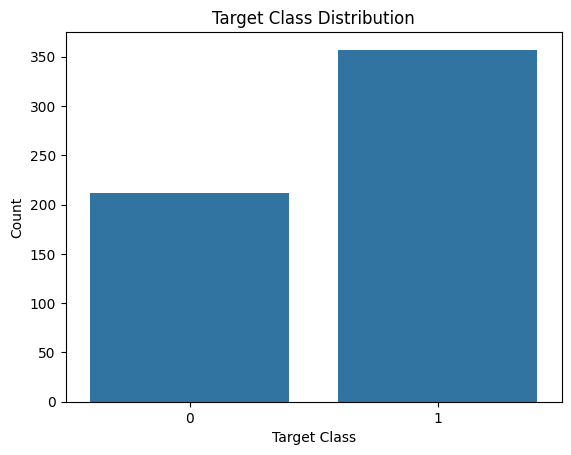

In [6]:
# Check target distribution

print(y.value_counts())

sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()

## 2. Train-Test Split

The dataset is divided into training and testing subsets.

The training set is used to learn the model, while the testing set is used to evaluate how well the trained model generalizes to unseen data.

In [7]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


## 3. Decision Tree Baseline

A Decision Tree is used as the baseline model.

It recursively divides the data using feature-based decision rules to classify observations.

The performance of this single tree will later be compared with the Random Forest model.

In [8]:
# Create Decision Tree model

decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Train the model

decision_tree.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [9]:
# Make predictions

dt_train_pred = decision_tree.predict(X_train)
dt_test_pred = decision_tree.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [10]:
# Calculate Decision Tree performance

dt_train_accuracy = accuracy_score(y_train, dt_train_pred)
dt_test_accuracy = accuracy_score(y_test, dt_test_pred)

dt_precision = precision_score(y_test, dt_test_pred)
dt_recall = recall_score(y_test, dt_test_pred)
dt_f1 = f1_score(y_test, dt_test_pred)

print("Decision Tree Performance")
print("-------------------------")
print("Training Accuracy :", round(dt_train_accuracy, 4))
print("Testing Accuracy  :", round(dt_test_accuracy, 4))
print("Precision         :", round(dt_precision, 4))
print("Recall            :", round(dt_recall, 4))
print("F1 Score          :", round(dt_f1, 4))

Decision Tree Performance
-------------------------
Training Accuracy : 1.0
Testing Accuracy  : 0.9123
Precision         : 0.9559
Recall            : 0.9028
F1 Score          : 0.9286


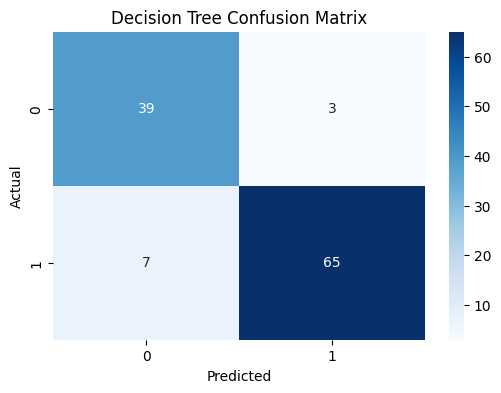

In [11]:
# Confusion Matrix - Decision Tree

dt_cm = confusion_matrix(y_test, dt_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 4. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines predictions from multiple decision trees.

Instead of relying on one tree, Random Forest creates multiple trees using different samples/features and combines their predictions.

This can reduce dependence on a single tree and often improves generalization.

In [12]:
# Create Random Forest classifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Random Forest

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [13]:
# Generate Random Forest predictions

rf_train_pred = random_forest.predict(X_train)
rf_test_pred = random_forest.predict(X_test)

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [14]:
# Calculate Random Forest performance

rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)

rf_precision = precision_score(y_test, rf_test_pred)
rf_recall = recall_score(y_test, rf_test_pred)
rf_f1 = f1_score(y_test, rf_test_pred)

print("Random Forest Performance")
print("-------------------------")
print("Training Accuracy :", round(rf_train_accuracy, 4))
print("Testing Accuracy  :", round(rf_test_accuracy, 4))
print("Precision         :", round(rf_precision, 4))
print("Recall            :", round(rf_recall, 4))
print("F1 Score          :", round(rf_f1, 4))

Random Forest Performance
-------------------------
Training Accuracy : 1.0
Testing Accuracy  : 0.9561
Precision         : 0.9589
Recall            : 0.9722
F1 Score          : 0.9655


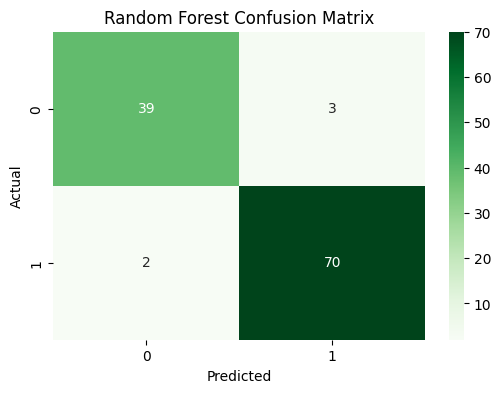

In [15]:
# Confusion Matrix - Random Forest

rf_cm = confusion_matrix(y_test, rf_test_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
# Compare Decision Tree and Random Forest

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Training Accuracy": [
        dt_train_accuracy,
        rf_train_accuracy
    ],
    "Testing Accuracy": [
        dt_test_accuracy,
        rf_test_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        dt_f1,
        rf_f1
    ]
})

comparison.round(4)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score
0,Decision Tree,1.0,0.9123,0.9559,0.9028,0.9286
1,Random Forest,1.0,0.9561,0.9589,0.9722,0.9655


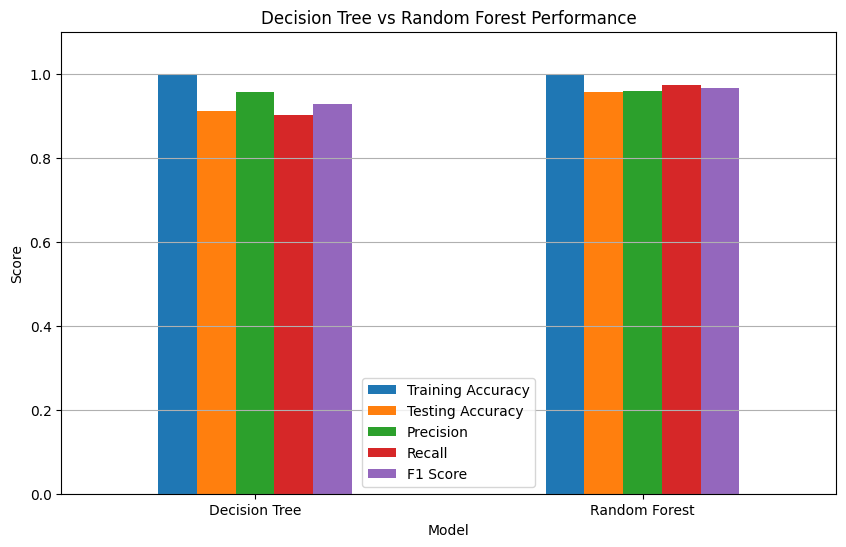

In [17]:
# Visual comparison of model performance

comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Decision Tree vs Random Forest Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")

plt.show()

## 5. Experiment with Number of Trees

The `n_estimators` parameter controls the number of decision trees in the Random Forest.

Different values are tested to observe how the number of trees affects testing performance.

In [18]:
# Experiment with different numbers of trees

n_estimators_values = [10, 50, 100, 200]

results = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    results.append({
        "n_estimators": n,
        "Training Accuracy": train_score,
        "Testing Accuracy": test_score
    })

estimator_results = pd.DataFrame(results)

estimator_results.round(4)

,n_estimators,Training Accuracy,Testing Accuracy
0,10,0.9956,0.9386
1,50,1.0000,0.9561
2,100,1.0000,0.9561
3,200,1.0000,0.9561


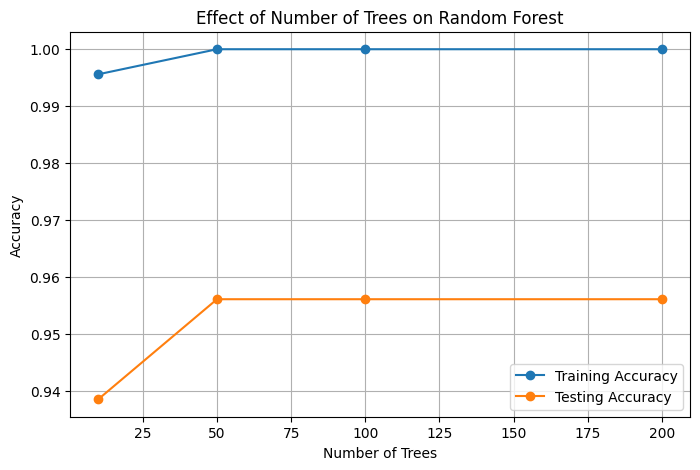

In [19]:
# Plot effect of number of trees

plt.figure(figsize=(8, 5))

plt.plot(
    estimator_results["n_estimators"],
    estimator_results["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    estimator_results["n_estimators"],
    estimator_results["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Effect of Number of Trees on Random Forest")
plt.legend()
plt.grid(True)

plt.show()

## 6. Feature Importance Analysis

Feature importance indicates how much each feature contributes to the decisions made by the Random Forest model.

The `feature_importances_` attribute is used to obtain these values.

In [20]:
# Extract feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


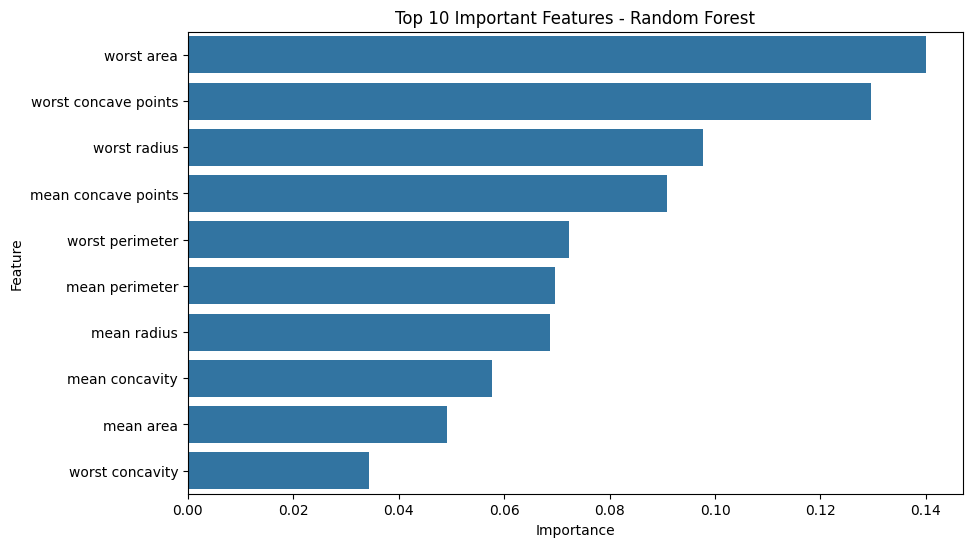

In [21]:
# Plot top 10 important features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [22]:
# Classification report

print("Random Forest Classification Report")
print("-----------------------------------")

print(
    classification_report(
        y_test,
        rf_test_pred,
        target_names=data.target_names
    )
)

Random Forest Classification Report
-----------------------------------
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# 7. Final Results and Conclusion

## Results

The Random Forest classifier was trained using multiple decision trees and its performance was compared with a single Decision Tree classifier.

The comparison considered:

- Training accuracy
- Testing accuracy
- Precision
- Recall
- F1-score

The effect of the `n_estimators` parameter was also analysed using different numbers of trees.

Feature importance analysis was performed to identify the features that contributed most strongly to the Random Forest's predictions.

## Conclusion

The experiment demonstrates the concept of ensemble learning by comparing a single Decision Tree with a Random Forest model. Random Forest combines multiple decision trees, which can reduce dependence on an individual tree and improve generalization.

The final model performance should be interpreted using the testing metrics rather than training accuracy alone.